<a name="top" id="top"></a>

<div align="center">
    <h1>Graver Augmentation Multiseed Algorithm
    </h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/AzAINN">Azain Khalid</a>
    <br>
    <i>Department of Computer Science, Purdue University</i>
    <br>
    <i> Undergraduate Researcher</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/JuliaQUBO/QUBONotebooks/blob/main/notebooks_jl/3-GAMA.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

## Setup

### Google Colab
Click the badge above to open this notebook in Colab. The notebook installs or activates dependencies in the setup cells below.

### Local installation
Run the following from the repository root before opening this notebook locally:

```bash
julia --project=notebooks_jl -e 'using Pkg; Pkg.instantiate()'
```

Run the command from the repository root before opening the Julia notebook locally.


## Colab Instructions

If not in a Colab notebook, continue to the next section.

1. Work on a copy of this notebook: _File_ > _Save a copy in Drive_.
2. Make sure the runtime is set to **Julia**. If Colab opens a Python runtime, use _Runtime_ > _Change runtime type_ and select Julia.
3. Execute the following setup cell to clone the repository when needed, activate the shared notebook project, and install dependencies. The first Colab run can take several minutes.


In [1]:
function load_qubonotebooks_bootstrap()
    candidates = (
        joinpath(pwd(), "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "..", "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "QUBONotebooks", "scripts", "notebook_bootstrap.jl"),
        joinpath("/content", "QUBONotebooks", "scripts", "notebook_bootstrap.jl"),
    )

    for candidate in candidates
        if isfile(candidate)
            include(candidate)
            return nothing
        end
    end

    in_colab = haskey(ENV, "COLAB_RELEASE_TAG") || haskey(ENV, "COLAB_JUPYTER_IP") || isdir(joinpath("/content", "sample_data"))
    if in_colab
        repo_dir = get(ENV, "QUBONOTEBOOKS_REPO_DIR", joinpath(pwd(), "QUBONotebooks"))
        if !isdir(repo_dir)
            println("[bootstrap] Cloning JuliaQUBO/QUBONotebooks into $repo_dir")
            run(`git clone --quiet --depth 1 https://github.com/JuliaQUBO/QUBONotebooks.git $repo_dir`)
        end
        include(joinpath(repo_dir, "scripts", "notebook_bootstrap.jl"))
        return nothing
    end

    error("Could not locate scripts/notebook_bootstrap.jl from $(pwd()).")
end

load_qubonotebooks_bootstrap()

BOOTSTRAP = Base.invokelatest(QUBONotebooksBootstrap.bootstrap_notebook, "3-GAMA")

QUBONOTEBOOKS_REPO_DIR = BOOTSTRAP.repo_dir
JULIA_NOTEBOOKS_DIR = BOOTSTRAP.notebooks_dir
JULIA_PROJECT_DIR = BOOTSTRAP.project_dir
IN_COLAB = BOOTSTRAP.in_colab;


### Activate Environment

In [2]:
import Pkg

python_warning_filter = "ignore:invalid escape sequence:SyntaxWarning"
python_warning_filters = String.(filter(!isempty, split(get(ENV, "PYTHONWARNINGS", ""), ",")))
if python_warning_filter ∉ python_warning_filters
    push!(python_warning_filters, python_warning_filter)
    ENV["PYTHONWARNINGS"] = join(python_warning_filters, ",")
end

if @isdefined(JULIA_PROJECT_DIR)
    Pkg.activate(JULIA_PROJECT_DIR; io = devnull)
else
    Pkg.activate(@__DIR__; io = devnull)
end
Pkg.instantiate(; io = devnull, allow_autoprecomp = false)


## Learning objectives

By the end of this notebook you will be able to:

1. Explain how Graver-basis directions can augment feasible integer solutions.
2. Run the GAMA workflow on a nonlinear integer programming instance using Julia tooling.
3. Compare complete and sampled Graver bases across objective improvement, iterations, and runtime.
4. Interpret the speed-quality tradeoff between exact augmentation data and smaller sampled direction sets.


## Prerequisites

**Mathematical background:** Integer programming, feasible sets, nonlinear objective functions, and basic runtime comparisons.  
**Prior notebooks:** Notebook 2 (QUBO) and the binary/integer modeling ideas from Notebook 1.  
**Accounts required:** None; optional 4ti2 support can compute larger Graver bases.  
**Julia version:** Julia 1.10+ with the notebook project environment instantiated.


## About this notebook

This notebook makes simple computations of Graver basis.
Because of the complexity of these computation, we suggest that for more complicated problems you install the excellent **[4ti2](https://4ti2.github.io/)** software, an open-source implementation of several routines useful for the study of integer programming through algebraic geometry.
It can be used as a stand-alone library and call it from C++ or directly from Julia.
In Julia, a binding is provided by **[lib4ti2_jll](https://github.com/JuliaBinaryWrappers/lib4ti2_jll.jl)**.

## Introduction to GAMA

The Graver Augmentation Multiseed Algorithm (GAMA) was proposed by [two](https://arxiv.org/abs/1902.04215) [papers](https://arxiv.org/abs/1907.10930) by Alghassi, Dridi, and Tayur from the CMU Quantum Computing group.
The three main ingredients of this algorithm, designed to solve integer programs with linear constraints and nonlinear objective, are:

- Computing the Graver basis (or a subset of it) of an integer program.
- Performing an augmentation.
- Given that only for certain objective functions, the Graver augmentation is guaranteed to find a globally optimal solution, the algorithm is initialized in several points.

This algorithm can be adapted to take advantage of Quantum Computers by leveraging them as black-box Ising/QUBO problem solvers.
In particular, obtaining several feasible solution points for the augmentation and computing the Kernel of the constraint matrix can be posed as QUBO problems.
After obtaining these solutions, other routines implemented in classical computers are used to solve the optimization problems, making this a hybrid quantum-classical algorithm.

### Introduction to Graver basis computation

A Graver basis is defined as

$$
\mathcal{G}(\mathbf{A}) = \bigcup_{j} \mathcal{H}_{j}(\mathbf{A})
$$

where $\mathcal{H}_{j}(\mathbf{A})$ are the minimal Hilbert basis of $\mathbf{A}$ in each orthant.

Equivalently we can define the Graver basis as the $\sqsubseteq$-minimal set of a lattice

$$
\mathcal{L}(\mathbf{A}) = \left\lbrace{}{\mathbf{x} : \mathbf{A} \mathbf{x} = 0, \mathbf{x} \in \mathbb{Z}^{n}}\right\rbrace{} \setminus \left\lbrace{}{0}\right\rbrace{} = \ker A \cap \mathbb{Z}^{n}
$$

where the partial ordering $\mathbf{x} \sqsubseteq \mathbf{y}$ holds whenever $x_i y_i \geq 0$ and $\left\vert x_i \right\vert \leq \left\vert y_i \right\vert$ for all $i$.

Here we won't interact with the Quantum Computer.
However, we will obtain the Graver basis of a problem using package 4ti2.
This notebook studies the behavior of the search algorithm in the case that we only have available a subset of the Graver basis.

## Problem statement

We will be solving EXAMPLE 4 in the code, which corresponds to Case 2 in the original GAMA paper.
The problem is derived from finance and deals with the maximization of expected returns on investments and the minimization of the variance.

$$
\begin{array}{rll}
    \displaystyle \min & \displaystyle -\sum_{i = 1}^{n} \mu_{i} x_{i} + \sqrt{\frac{1 - \varepsilon}{\varepsilon} \sum_{i = 1}^{n} \sigma_{i}^2 x_{i}^2 } \\
    \textrm{s.t.}      & A \mathbf{x} = \mathbf{b} \\
    ~                  & \mathbf{x} \in \left\lbrace{}{-2, -1, 0, 1, 2}\right\rbrace{}^{n}
\end{array}
$$

In [3]:
# QUBONOTEBOOKS_COLAB_IMPORT_CELL
Base.invokelatest(
    QUBONotebooksBootstrap.load_notebook_packages!,
    "DelimitedFiles and Random",
    :(begin
        using DelimitedFiles
        using Random
    end),
);


In [4]:
const ε_default = 0.01

function shared_data_path(filename::AbstractString)
    project = Base.current_project()
    project_dir = project === nothing ? pwd() : dirname(project)
    candidates = [
        joinpath(project_dir, "..", "notebooks_data", filename),
        joinpath(pwd(), "notebooks_data", filename),
        joinpath(pwd(), "..", "notebooks_data", filename),
        joinpath("/content", "QUBONotebooks", "notebooks_data", filename),
        joinpath("/content", "notebooks_data", filename),
    ]

    for candidate in candidates
        if isfile(candidate)
            return abspath(candidate)
        end
    end

    return nothing
end

function load_portfolio_coefficients(num_variables::Integer)
    coeff_path = shared_data_path("3-GAMA_example4_coefficients.csv")

    if coeff_path !== nothing
        coeffs = readdlm(coeff_path, ',', Float64)
        if size(coeffs) != (2, num_variables)
            error("Expected coefficient data with shape (2, $(num_variables)); found $(size(coeffs)).")
        end

        return collect(coeffs[1, :]), collect(coeffs[2, :])
    end

    rng = MersenneTwister(1729)
    μ = rand(rng, num_variables)
    σ = rand(rng, num_variables) .* μ

    return μ, σ
end

const PORTFOLIO_COEFFICIENTS_DEFAULT = load_portfolio_coefficients(25)
const μ_default = PORTFOLIO_COEFFICIENTS_DEFAULT[1]
const σ_default = PORTFOLIO_COEFFICIENTS_DEFAULT[2]

function f(x; μ=μ_default, σ=σ_default, ε=ε_default)
    return μ'x + sqrt(((1 - ε) / ε) * (σ .^ 2)' * (x .^ 2))
end


f (generic function with 1 method)

### Example

Let

$$
A = \begin{bmatrix}
1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 0 & 1 & 0 & 1 & 0 \\
1 & 1 & 1 & 1 & 0 & 1 & 0 & 1 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1 & 1 \\
0 & 1 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 0 & 0 & 1 & 0 & 0 & 1 & 1 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 1 & 1 & 1 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 1 & 0 \\
\end{bmatrix}
$$

This particular instance of convex INLP has $m = 5$, $n = 25$, $\varepsilon = 0.01$, $\mu_{i} = \textrm{rand}[0, 1]$, $\sigma_{i} = \textrm{rand}[0, \mu_{i}]$.
$A \in \mathbb{B}^{m \times n}$ and each $b_{j}$ is half the sum of the $j$-th row of $A$.
In this example, $\mathbf{b} = \left({9, 8, 7, 5, 5}\right)'$.

First we would write this problem as a an unconstrained one by penalizing the linear constraints as quadratics in the objective.
Let's first define the problem parameters.

In [5]:
A = [
    1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 1 0 1 0
    1 1 1 1 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 1 1
    0 1 0 0 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 1 0 0 1 1 1
    0 0 0 0 0 0 0 1 0 1 1 1 0 1 1 1 1 0 0 1 0 0 0 0 0
    0 1 1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0
]

m, n = size(A)

b = vec(ceil.(Int, sum(A; dims = 2) / 2));

In [6]:
x0 = [1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, -2, 1, 0, -1, 0, 1, -1, 1, -2, -2, 1, 1, 1]

xl = fill(-2, n)
xu = fill( 2, n);

In [7]:
ε = ε_default
μ = μ_default       # ~ [0, 1]
σ = σ_default;      # ~ [0, μ]

In [8]:
# QUBONOTEBOOKS_COLAB_IMPORT_CELL
Base.invokelatest(
    QUBONotebooksBootstrap.load_notebook_packages!,
    "4ti2 dependencies",
    :(begin
        import lib4ti2_jll
        import BinaryWrappers
        using DelimitedFiles
        using Downloads
        using NPZ
    end),
);


In [9]:
const lib4ti2_bin = BinaryWrappers.@generate_wrappers(lib4ti2_jll)

function has_graver()::Bool
    try
        return success(`$(lib4ti2_bin)/graver --help`)
    catch
        return false
    end
end

function graver()
    run(`$(lib4ti2_bin)/graver --help`)

    return nothing
end

function graver(proj_path::AbstractString; silent::Bool = true)
    if silent
        run(`$(lib4ti2_bin)/graver -q $(proj_path)`)
    else
        run(`$(lib4ti2_bin)/graver $(proj_path)`)
    end

    return nothing
end

function write_mat(path::AbstractString, A)
    m, n = size(A)

    open(path, "w") do io
        println(io, "$m $n")

        join(io, (join(@view(A[i, :]), " ") for i = 1:m), "\n")
    end

    return nothing
end

function read_mat(path::AbstractString, type = Int)
    m, n = parse.(Int, split(readline(path)))

    A = Matrix{type}(undef, m, n)

    open(path, "r") do io
        readline(io)

        for (i, line) in enumerate(eachline(io))
            A[i, :] .= parse.(Int, split(line))
        end
    end

    return A
end

# Compute graver basis locally
function compute_graver_basis_local(A, xl, xu)
    G = nothing

    mktempdir() do path
        proj_path = joinpath(path, "proj")

        write_mat("$(proj_path).mat", A)
        write_mat("$(proj_path).lb", xl)
        write_mat("$(proj_path).ub", xu)

        graver(proj_path)

        G = read_mat("$(proj_path).gra")
    end

    return G    
end

const GRAVER_BASIS_URL = "https://github.com/JuliaQUBO/QUBONotebooks/raw/main/notebooks_jl/graver.npy"

function graver_basis_path()
    project = Base.current_project()
    project_dir = project === nothing ? pwd() : dirname(project)
    candidates = [
        joinpath(project_dir, "graver.npy"),
        joinpath(pwd(), "graver.npy"),
        joinpath(pwd(), "notebooks_jl", "graver.npy"),
        joinpath("/content", "QUBONotebooks", "notebooks_jl", "graver.npy"),
        joinpath("/content", "graver.npy"),
    ]

    for candidate in candidates
        if isfile(candidate)
            return abspath(candidate)
        end
    end

    download_path = isdir("/content") ? joinpath("/content", "graver.npy") : joinpath(project_dir, "graver.npy")
    Downloads.download(GRAVER_BASIS_URL, download_path)

    return download_path
end

# Fallback: load/download the pre-computed graver basis and read with NPZ.jl  
function download_graver_basis()
    npy_path = graver_basis_path()
    G = NPZ.npzread(npy_path)
    return Array{Int}(G)
end


function graver_basis(A, xl, xu)
    if has_graver()
        return compute_graver_basis_local(A, xl, xu)
    else
        return download_graver_basis()
    end
end
 


graver_basis (generic function with 1 method)

In [10]:
G = graver_basis(A, xl', xu')

26292×25 Matrix{Int64}:
 0   0   0   0   0   0  1  0  0   0   0  …   0  0  0  -1  0   0  0  0   0  0
 1   0   0   0   0   0  0  0  0   0   0      0  0  0  -1  0  -1  0  0   0  0
 0   0   0   0   0   0  0  0  1   0   0      0  0  0  -1  0   0  0  0   0  0
 0   0   0   0   0   0  0  0  0   0   0      0  0  1  -1  0  -1  0  0   0  0
 0   1  -1   0   0   0  0  0  0   0   0      0  0  0   0  0   0  0  0   0  0
 0   1   0  -1   0   0  0  0  0   0   0  …   0  0  0   0  0   0  0  0   0  0
 0   1   0   0  -1   0  0  0  0   0   0      0  0  0   0  0  -1  0  0   0  0
 0   1   0   0   0  -1  0  0  0   0   0      0  0  0   0  0   0  0  0   0  0
 0   1   0   0   0   0  0  1  0  -1   0      0  0  0  -1  0  -2  0  0   0  0
 0   0   0   0   0   0  0  1  0   0  -1      0  0  0  -1  0   0  0  0   0  0
 0   0   0   0   0   0  0  1  0   0   0  …   0  0  0   0  0  -1  0  0   0  0
 0   1   0   0   0   0  0  1  0   0   0      0  0  0  -1  0  -2  0  0   0  0
 0   0   0   0   0   0  0  1  0   0   0      0  0  0

In [11]:
# Define rules to choose augmentation element, either the best one (argmin) or the first one that is found
function argmin_rule(a)
    local i, y, α = (nothing, NaN, Inf)

    for (_i, (_y, _α)) in enumerate(a)
        if _α < α
            i, y, α = (_i, _y, _α)
        end
    end

    return (i, (y, α))
end

function greedy_rule(a)
    local i, y, α = (nothing, NaN, Inf)

    for (_i, (_y, _α)) in enumerate(a)
        if _α ≉ 0.0
            return (_i, (_y, _α))
        else
            i, y, α = (_i, _y, _α)
        end
    end

    return (i, (y, α))
end

greedy_rule (generic function with 1 method)

In [12]:
# Bisection rules for finding best step size
function bisection_rule(f::Function, g, x, xl = nothing, xu = nothing, laststep = nothing)
    if g == laststep
        return (f(x), 0)
    end

    if xl === nothing
        xl = zeros(length(x))
    end

    if xu === nothing
        xu = fill(2 * maximum(x),length(x))
    end

    u = maximum(xu) - minimum(xl)
    l = -u

    for (i, gi) in enumerate(g)
        if gi >= 1
            u = min(u, floor(Int, (xu[i] - x[i]) / gi))
            l = max(l, ceil(Int, (xl[i] - x[i]) / gi))
        elseif gi <= -1
            u = min(u, floor(Int, (xl[i] - x[i]) / gi))
            l = max(l, ceil(Int, (xu[i] - x[i]) / gi))
        end
    end

    α = u

    while u - l > 1
        α = ifelse(f(x + l*g) < f(x + u*g), l, u)

        p1 = floor(Int, (l+u)/2) - 1
        p2 = floor(Int, (l+u)/2)
        p3 = floor(Int, (l+u)/2) + 1

        if f(x + p1*g) < f(x + p2*g)
            u = floor(Int, (l+u)/2)
        elseif f(x + p3*g) < f(x + p2*g)
            l = floor(Int, (l+u)/2) + 1
        else
            α = p2
            break
        end
    end

    if f(x + l*g) < f(x + u*g) && f(x + l*g) < f(x + α*g)
        α = l
    elseif f(x + u*g) < f(x + α*g)
        α = u
    end

    return (f(x + α*g), α)
end

# We can just have a single step move (works well with greedy approach)
function single_move_rule(f::Function, g, x, xl = nothing, xu = nothing, laststep = nothing)
    if xl === nothing
        xl = zeros(length(x))
    end

    if xu === nothing
        xu = fill(2 * maximum(x),length(x))
    end

    α = 0

    if all(x + g .<= xu) && all(x + g .>= xl)
        if f(x + g) < f(x)
            α = 1
        end
    elseif all(x - g .<= xu) && all(x - g .>= xl)
        if f(x - g) < f(x) && f(x - g) < f(x + g)
            α = -1
        end
    end

    return (f(x + α*g), α)
end

single_move_rule (generic function with 4 methods)

In [13]:
function augmentation(
    f::Function,
    A,
    b,
    x0,
    xl,
    xu;
    silent::Bool = true,
    max_iter::Integer = 1_000,
    step_rule::Function = bisection_rule,
    choice_rule::Function = argmin_rule,
    )
    G = graver_basis(A, xl', xu')

    return augmentation(
        f,
        G,
        A,
        b,
        x0,
        xl,
        xu;
        silent,
        max_iter,
        step_rule,
        choice_rule,
    )
end

function augmentation(
    f::Function,
    G,
    A,
    b,
    x0,
    xl,
    xu;
    silent::Bool = true,
    max_iter::Integer = 1_000,
    step_rule::Function = bisection_rule,
    choice_rule::Function = argmin_rule,
    )
    # Let's perform the augmentation and return the number of steps and the best solution

    # Constraints definition
    isfeasible = (x) -> (A * x == b)

    Δ = 1
    n = length(x0)
    k = 1

    if !silent
        println("Initial point: $(x0)")
        println("Objective function: $(f(x0))")
    end

    
    y = nothing
    x = copy(x0)
    δ = Vector{Int}(undef, n)
    gprev = fill(typemin(Int), n)  # sentinel: cannot match a real Graver basis element

    while Δ != 0 && k < max_iter
        i, (y, Δ) = choice_rule((step_rule(f, g, x, xl, xu, gprev) for g in eachrow(G)))

        δ .= @view(G[i,:]) .* Δ 
        x .+= δ
        gprev .= @view(G[i,:])

        if !silent
            println("Iteration ", k)
            println(i, (y, Δ))
            println("Augmentation direction:", gprev)
            println("Distanced moved:", Δ)
            println("Step taken:", δ)
            println("Objective function:", y)
            println(f(x))
            println("Current point:", x)
            println("Are constraints satisfied?", isfeasible(x))
        end

        k += 1
    end

    return (k, y, x)
end

augmentation (generic function with 2 methods)

First, we will prove our augmentation strategies, either best or greedy, and for that last case, either computing the best step or a single move.
In the order that was mentioned, the augmentation will take more iterations, but each one of the augmentation steps or iterations is going to be cheaper.



In [14]:
println("Best-augmentation: Choosing among the best step that each element of G can do (via bisection), the one that reduces the most the objective")

iter, f_obj, xf = @time augmentation(
    f, G, A, b, x0, xl, xu;
    step_rule = bisection_rule, choice_rule = argmin_rule
)

println("$(iter), iterations")
println("solution: $(xf)")
println("objective: $(f_obj)")

println("Greedy-best-augmentation: Choosing among the best step that each element of G can do (via bisection), the first one encountered that reduces the objective")

iter,f_obj,xf = @time augmentation(
    f, G, A, b, x0, xl, xu;
    step_rule = bisection_rule, choice_rule = greedy_rule,
)

println("$(iter), iterations")
println("solution: $(xf)")
println("objective: $(f_obj)")

println("Greedy-augmentation: Choosing among the first element of G that with a single step reduces the objective")

iter,f_obj,xf = @time augmentation(
    f, G, A, b, x0, xl, xu;
    step_rule = single_move_rule, choice_rule = greedy_rule,
)

println("$(iter), iterations")
println("solution: $(xf)")
println("objective: $(f_obj)")

Best-augmentation: Choosing among the best step that each element of G can do (via bisection), the one that reduces the most the objective


  1.256934 seconds (15.10 M allocations: 3.295 GiB, 4.59% gc time, 51.98% compilation time)
21, iterations
solution: [-2, 1, 1, 0, 0, 0, 1, 2, 0, -1, 2, 2, 0, 0, -1, -1, 0, 1, 1, 2, 0, 0, 0, 2, 0]
objective: 6.922060643119407
Greedy-best-augmentation: Choosing among the best step that each element of G can do (via bisection), the first one encountered that reduces the objective
  0.184747 seconds (896.77 k allocations: 187.886 MiB, 3.65% gc time, 78.80% compilation time)


34, iterations
solution: [2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 0, 0, -1, -1, 1, 0, 0, 1, 0, 0, 0, 2, -2]
objective: 2.2955158390660966
Greedy-augmentation: Choosing among the first element of G that with a single step reduces the objective


  0.484587 seconds (1.12 M allocations: 120.456 MiB, 2.63% gc time, 94.80% compilation time)
31, iterations
solution: [2, 2, 0, 0, 0, 0, 1, 2, 0, 0, 2, 0, 0, 0, 0, -1, 1, 0, 0, 1, -1, 0, 0, 2, -2]
objective: 2.329468812366131


In [15]:
# QUBONOTEBOOKS_COLAB_IMPORT_CELL
Base.invokelatest(
    QUBONotebooksBootstrap.load_notebook_packages!,
    "JuMP and LinearAlgebra",
    :(using JuMP, LinearAlgebra),
);

const HAS_DWAVE = try
    Base.invokelatest(
        QUBONotebooksBootstrap.load_notebook_packages!,
        "DWave",
        :(using DWave),
    );
    true
catch e
    @warn "DWave.jl not available. Feasible-start QUBO sampling will use bundled starts instead." exception=(e, catch_backtrace())
    false
end;


In [16]:
function load_precomputed_feasible_starts()
    starts_path = shared_data_path("3-GAMA_example4_feasible_starts.csv")
    if starts_path === nothing
        return nothing
    end

    starts = readdlm(starts_path, ',', Int)
    starts = ndims(starts) == 1 ? reshape(starts, 1, :) : starts

    return [collect(row) for row in eachrow(starts)]
end

function get_feasible(A, b; num_reads=1_000)
    if !HAS_DWAVE
        X = load_precomputed_feasible_starts()
        if X !== nothing
            println("DWave.jl is unavailable; loaded $(length(X)) precomputed feasible solutions.")
            return X
        end

        error("DWave.jl is unavailable and 3-GAMA_example4_feasible_starts.csv was not found.")
    end

    m, n = size(A)

    Q = A'A - 2 * diagm(A'b)
    β = b'b

    # Define Binary Quadratic Model using new DWave.jl
    model = Model(DWave.Neal.Optimizer)

    @variable(model, x[1:n], Bin)

    @objective(model, Min, x' * Q * x + β)

    set_optimizer_attribute(model, "num_reads", num_reads)

    optimize!(model)

    X = [
        round.(Int, value.(x; result=i))
        for i = 1:result_count(model)
        if objective_value(model; result=i) ≈ 0.0
    ]

    println("$(length(X)) feasible solutions found.")

    return X
end

get_feasible (generic function with 1 method)

In [17]:
X_feas = get_feasible(A,b; num_reads = 20);

20 feasible solutions found.


We take 20 samples using DWave.jl's local simulated annealing backend and notice that most (if not all of them) are feasible and different.
If DWave.jl is not available in the active environment, the notebook loads the committed feasible starts from `notebooks_data/3-GAMA_example4_feasible_starts.csv` so the augmentation sections still run.
D-Wave QPU workflows require a D-Wave Leap account and `DWAVE_API_TOKEN`, but this section does not contact a QPU.
Let's now apply the augmentation procedure to each one of them and record the final objective and the number of iterations it takes.
Here we will use the 3rd augmentation strategy (Greedy) because of runtime.

In [18]:
function augmentation_experiment(f, G, A, b, X, xl, xu)
    K = length(X)

    Y = Vector{Float64}(undef, K)
    I = Vector{Int}(undef, K)
    T = Vector{Float64}(undef, K)

    for (i, x) in enumerate(X)
        result = @timed augmentation(
            f, G, A, b, x, xl, xu;
            step_rule   = single_move_rule,
            choice_rule = greedy_rule,
        )

        num_iter, obj_val, _ = result.value

        Y[i] = obj_val
        I[i] = num_iter
        T[i] = result.time
    end

    return (Y, I, T)
end

Y_feas = f.(X_feas)

Y_aug, I_aug, T_aug = augmentation_experiment(f, G, A, b, X_feas, xl, xu);

We record the initial objective function, the one after doing the augmentation, and the number of augmentation steps.

In [19]:
# QUBONOTEBOOKS_COLAB_IMPORT_CELL
Base.invokelatest(
    QUBONotebooksBootstrap.load_notebook_packages!,
    "plotting and statistics packages",
    :(using Measures, Random, Plots, StatsBase, StatsPlots),
);


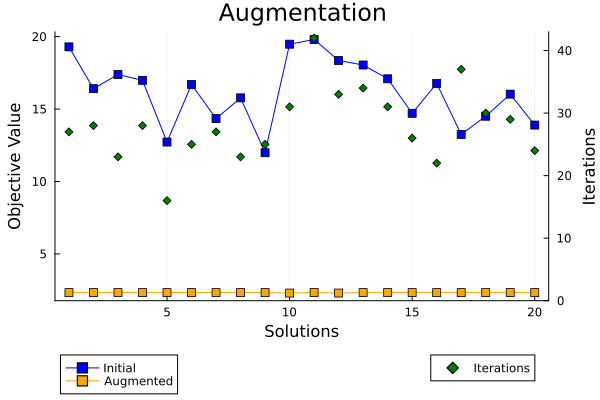

In [20]:
function plot_augmentation(Y_feas, Y_aug, I_aug)
    plt = plot(;
        plot_title = "Augmentation",
        bottom_margin = 15mm,
    )

    plot!(
        plt, Y_feas;
        label       = "Initial",
        color       = :blue,
        markershape = :square,
    )
    plot!(
        plt, Y_aug;
        label       = "Augmented",
        color       = :orange,
        markershape = :square,
        ylabel      = "Objective Value",
        xlabel      = "Solutions",
        legend      = (0.1, -0.25),
    )

    scatter!(
        twinx(plt), I_aug;
        label       = "Iterations",
        color       = :green,
        legend      = (0.85, -0.25),
        markershape = :diamond,
        ylabel      = "Iterations",
        ylims       = (0, maximum(I_aug) + 1),
    )

    return plt
end

plot_augmentation(Y_feas, Y_aug, I_aug)

Notice that we reach the globally optimal solution regardless of the initial point and that even if the initial objective was closer to the optimal objective function, it might take more iterations to reach the optimum.

Now let's try an extreme case, where we only have 10 of the elements of the Graver basis.

In [21]:
function partial_augmentation_experiment(f, G, A, b, X, xl, xu; seed = nothing, num_samples = 10)
    K = length(X)

    Y = Vector{Float64}(undef, K)
    I = Vector{Int}(undef, K)
    T = Vector{Float64}(undef, K)

    index = sample(1:size(G,1), num_samples, replace = false)
    G_idx = G[index,:]

    for (i, x) in enumerate(X)
        result = @timed augmentation(
            f, G_idx, A, b, x, xl, xu;
            step_rule   = single_move_rule,
            choice_rule = greedy_rule,
        )

        num_iter, obj_val, _ = result.value

        Y[i] = obj_val
        I[i] = num_iter
        T[i] = result.time
    end

    return (Y, I, T)
end

Y_feas = f.(X_feas)

Y_paug, I_paug, T_paug = partial_augmentation_experiment(f, G, A, b, X_feas, xl, xu);

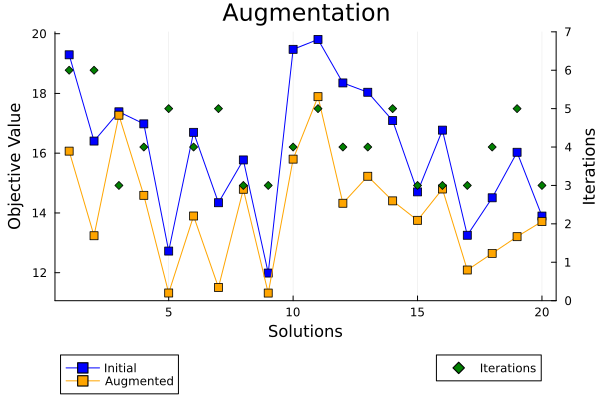

In [22]:
plot_augmentation(Y_feas, Y_paug, I_paug)

Here we can barely improve the objective and can only perform a few iterations before we cannot improve the solution.
But if we compare the runtimes in both cases, we find that...

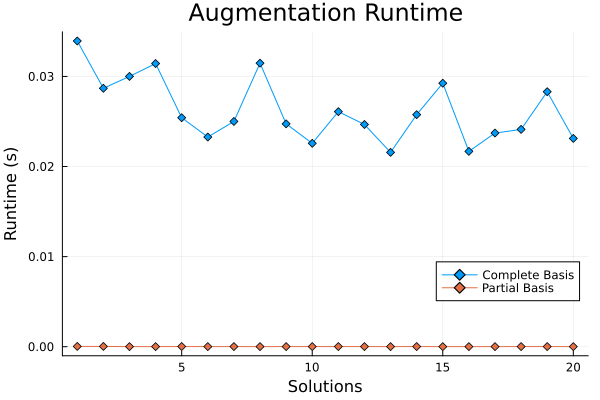

In [23]:
function plot_augmentation_runtime(T_aug, T_paug)
    plt = plot(;
        plot_title = "Augmentation Runtime",
        xlabel     = "Solutions",
        ylabel     = "Runtime (s)",
        legend     = (0.8, 0.25),
    )

    plot!(T_aug; label="Complete Basis", markershape=:diamond)
    plot!(T_paug; label="Partial Basis", markershape=:diamond)

    return plt
end

plot_augmentation_runtime(T_aug, T_paug)

...the time to do augmentation only having 10 choices is minimal.
We can search for a sweet spot in between, with good solutions and little time.

In [24]:
function multiple_partial_augmentation_experiment(f, G, A, b, X, xl, xu; seed = nothing)
    N = 10 # Discretization of the fractions of Graver considered
    M = length(X)
    K = size(G, 1)

    Y = Matrix{Float64}(undef, N, M)
    I = Matrix{Int}(undef, N, M)
    T = Matrix{Float64}(undef, N, M)
    
    for j in 1:N
        Y_p, I_p, T_p = partial_augmentation_experiment(
            f, G, A, b, X, xl, xu; num_samples = trunc(Int, K / N * j)
        )

        Y[j, :] .= Y_p
        I[j, :] .= I_p
        T[j, :] .= T_p
    end

    return (Y, I, T)
end

Y_mpaug, I_mpaug, T_mpaug = multiple_partial_augmentation_experiment(f, G, A, b, X_feas, xl, xu);

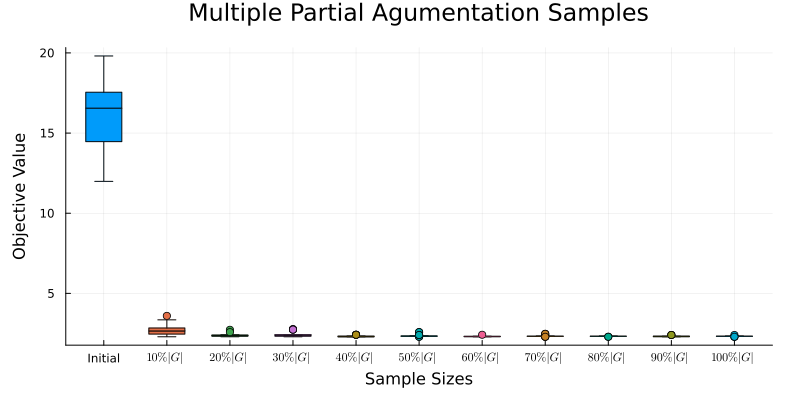

In [25]:
function plot_multiple_partial_augmentation(Y_feas, Y_mpaug)
    Y = hcat(Y_feas, Y_mpaug')
    X = permutedims(["Initial";["\$ $(10i) \\%|G| \$" for i = 1:10]])

    plt = boxplot(X, Y;
        plot_title = "Multiple Partial Agumentation Samples",
        size       = (800, 400),
        margin     = 5mm,
        ylabel     = "Objective Value",
        xlabel     = "Sample Sizes",
        legend     = false
    )

    return plt
end

plot_multiple_partial_augmentation(Y_feas, Y_mpaug)

## Practice checkpoints

Use these checkpoints during the workshop to test the main ideas before moving on.

In [26]:
# =============================================================================
# EXERCISE 1: Try a different starting point
# =============================================================================
# Select a feasible starting point different from the one used in the walkthrough and run the augmentation loop. Compare the objective path and final solution.
#
# Hint: Use the same Graver basis so the starting point is the only change.
#
# Your code here:
# =============================================================================

In [27]:
# SOLUTION (hidden in workshop version):
# Try a different feasible start on a toy augmentation path.
feasible_starts = [(3, 0), (2, 1), (1, 2)]
objective(point) = 4 * point[1] + point[2]
start = feasible_starts[2]
moves = [(-1, 1), (1, -1)]
path = [start]
for move in moves
    candidate = path[end] .+ move
    if candidate in feasible_starts && objective(candidate) < objective(path[end])
        push!(path, candidate)
    end
end
objectives = objective.(path)
println("start = $(start); path = $(path); objectives = $(objectives)")


start = (2, 1); path = [(2, 1), (1, 2)]; objectives = [9, 6]


In [28]:
# =============================================================================
# EXERCISE 2: Compare augmentation strategies
# =============================================================================
# Run the same instance with bisection and a single-move rule. Track the number of accepted augmentations and identify which strategy reaches the optimum faster.
#
# Hint: Use the same initial feasible point for both runs.
#
# Your code here:
# =============================================================================

In [29]:
# SOLUTION (hidden in workshop version):
# Compare first-improving and best-improving choices on the same candidate list.
candidates = [(5.0, "move_a"), (2.0, "move_b"), (3.0, "move_c")]
first_improving = first(filter(candidate -> candidate[1] < 6.0, candidates))
best_improving = sort(candidates; by = first)[1]
format_candidate(candidate) = string("(", candidate[1], ", \"", candidate[2], "\")")
println("first_improving = $(format_candidate(first_improving)); best_improving = $(format_candidate(best_improving))")


first_improving = (5.0, "move_a"); best_improving = (2.0, "move_b")


In [30]:
# =============================================================================
# EXERCISE 3: Modify the objective
# =============================================================================
# Change one objective coefficient and predict which Graver moves become more attractive. Re-run the augmentation and explain any change in the path.
#
# Hint: A coefficient change affects move selection without changing feasibility.
#
# Your code here:
# =============================================================================

In [31]:
# SOLUTION (hidden in workshop version):
# Show how changing an objective coefficient changes move gains.
moves = [(1, -1), (-1, 1), (0, 1)]
old_c = (4.0, 1.0)
new_c = (1.0, 4.0)
gains(coefficients) = [sum(coefficients[i] * move[i] for i in eachindex(move)) for move in moves]
old_gains = gains(old_c)
new_gains = gains(new_c)
println("old_gains = $(old_gains); new_gains = $(new_gains)")


old_gains = [3.0, -3.0, 1.0]; new_gains = [-3.0, 3.0, 4.0]


## Summary

In this notebook we:

- Introduced Graver-basis augmentation as a structured approach for improving feasible integer solutions.
- Applied augmentation directions to multiple feasible starts for a nonlinear integer program.
- Compared complete and sampled direction sets using objective values, iteration counts, and runtime plots.
- Used the experiments to reason about when smaller direction subsets may be faster but less reliable.

**Learning objectives met:** You practiced explaining Graver augmentation, running the GAMA workflow, comparing full and sampled bases, and interpreting the resulting runtime-quality tradeoff.

**Next steps:** Proceed to [Notebook 4: D-Wave](4-DWave.ipynb) to see how QUBO models can be sent to quantum annealing hardware or a local fallback sampler.

**Further reading:**
- [Alghassi, Dridi, and Tayur, arXiv:1902.04215](https://arxiv.org/abs/1902.04215)
- [Alghassi, Dridi, and Tayur, arXiv:1907.10930](https://arxiv.org/abs/1907.10930)
- [4ti2 documentation](https://4ti2.github.io/)


### References

- [QuIPML22](https://github.com/bernalde/QuIPML22/)

### Local Installation Instructions

To run the code locally install Julia. Consider using [juliaup](https://github.com/JuliaLang/juliaup).

In [32]:
# Validate Installation

versioninfo()

Julia Version 1.10.11
Commit a2b11907d7b (2026-03-09 14:59 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 36 × Intel(R) Xeon(R) w5-2565X
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, sapphirerapids)
Threads: 1 default, 0 interactive, 1 GC (on 36 virtual cores)
Environment:
  JULIA_DEPOT_PATH = <repository>/.julia-depot:<user-julia-depot>
  JULIA_PKG_PRECOMPILE_AUTO = 0
  JULIA_CONDAPKG_BACKEND = Null
  JULIA_PYTHONCALL_EXE = <repository>/.venv/bin/python3


<div align="center">
    <a href="#top">🔝 Go back to the top 🔝</a>
</div>